# Module 1: Time-Frequency Fundamentals

## The Central Question of Signal Analysis

Imagine you're listening to a orchestra. Your ears naturally tell you two things: *when* each instrument plays and *what notes* they play. But here's the challenge: when we record this performance digitally, we get just a sequence of numbers representing air pressure over time. How do we extract the "what" (frequencies) from the "when" (time samples)?
    "
    "This is the fundamental problem the Fourier Transform solves. In this module, you'll gain deep intuition about:
    "* How sampling converts continuous signals to digital form
    "* Why there's a maximum frequency you can detect (Nyquist limit)
    "* How the FFT extracts frequency information
    "* Why you can't have perfect time AND frequency resolution simultaneously
    "
    "Most importantly, you'll learn to choose the right analysis parameters for YOUR specific signals.n"

## Part 1: Sampling - From Analog to Digital

### The Sampling Process

Sampling is like taking snapshots of a continuous signal at regular intervals. The **sampling rate** (or sampling frequency) $f_s$ determines how many snapshots per second.

Key concepts:
* **Sampling period**: $T_s = 1/f_s$ (time between samples)
* **Nyquist frequency**: $f_{Nyquist} = f_s/2$ (highest detectable frequency)
* **Sampling theorem**: To perfectly reconstruct a signal, you must sample at least twice as fast as its highest frequency component

Let's see what happens when we sample at different rates:

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider, FloatSlider
import warnings
warnings.filterwarnings('ignore')

def sampling_demonstration(signal_freq, sample_rate):
    """Demonstrate the effect of sampling rate on signal reconstruction."""

    # Create a high-resolution "continuous" signal for reference
    t_continuous = np.linspace(0, 1, 5000)
    signal_continuous = np.sin(2 * np.pi * signal_freq * t_continuous)

    # Sample the signal
    t_samples = np.arange(0, 1, 1/sample_rate)
    signal_samples = np.sin(2 * np.pi * signal_freq * t_samples)

    # Interpolate to show reconstructed signal
    from scipy import signal
    if len(t_samples) > 1:
        t_recon = np.linspace(0, 1, 1000)
        signal_recon = np.interp(t_recon, t_samples, signal_samples)
    else:
        t_recon = t_continuous
        signal_recon = np.zeros_like(t_continuous)

    # Create figure
    fig, axes = plt.subplots(2, 1, figsize=(12, 8))
    
    # Top plot: Original and sampled signal
    axes[0].plot(t_continuous, signal_continuous, 'b-', alpha=0.3,
                linewidth=2, label='Original signal')
    axes[0].stem(t_samples, signal_samples, 'r', markerfmt='ro', 
                basefmt=' ', label=f'Samples ({sample_rate} Hz)')
    axes[0].set_title(f'Sampling a {signal_freq} Hz Signal at {sample_rate} Hz', 
                     fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Time (seconds)')
    axes[0].set_ylabel('Amplitude')
    axes[0].set_xlim(0, 0.1)  # Zoom in to see detail
    axes[0].grid(True, alpha=0.3)
    axes[0].legend(loc='upper right')
    
    # Add Nyquist information
    nyquist = sample_rate / 2
    if signal_freq <= nyquist:
        status = "✅ Signal frequency below Nyquist limit"
        color = 'green'
    else:
        status = "⚠️ ALIASING! Signal frequency above Nyquist limit"
        color = 'red'
    
    axes[0].text(0.02, 0.95, f'Nyquist frequency: {nyquist} Hz', 
                transform=axes[0].transAxes, fontsize=10, 
                verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat'))
    axes[0].text(0.02, 0.85, status, transform=axes[0].transAxes, 
                fontsize=10, verticalalignment='top', color=color, fontweight='bold')
    
    # Bottom plot: Frequency spectrum
    if len(t_samples) > 1:
        n = len(signal_samples)
        fft_freqs = np.fft.fftfreq(n, 1/sample_rate)
        fft_vals = np.fft.fft(signal_samples)
        
        # Only plot positive frequencies
        pos_mask = fft_freqs >= 0
        
        axes[1].stem(fft_freqs[pos_mask], np.abs(fft_vals[pos_mask])/n*2, 
                    'b', markerfmt='bo', basefmt=' ')
        axes[1].axvline(nyquist, color='red', linestyle='--', alpha=0.7, 
                       linewidth=2, label=f'Nyquist freq ({nyquist} Hz)')
        axes[1].axvline(signal_freq, color='green', linestyle=':', alpha=0.7, 
                       linewidth=2, label=f'True freq ({signal_freq} Hz)')
        
        if signal_freq > nyquist:
            # Show aliased frequency
            aliased_freq = np.abs(signal_freq - sample_rate * round(signal_freq/sample_rate))
            axes[1].axvline(aliased_freq, color='orange', linestyle=':', 
                           alpha=0.7, linewidth=2, 
                           label=f'Aliased freq ({aliased_freq:.1f} Hz)')

    axes[1].set_title('Frequency Spectrum of Sampled Signal', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Frequency (Hz)')
    axes[1].set_ylabel('Amplitude')
    axes[1].set_xlim(0, sample_rate/2 + 10)
    axes[1].grid(True, alpha=0.3)
    axes[1].legend(loc='upper right')

    plt.tight_layout()
    plt.show()

# Interactive controls
interact(sampling_demonstration,
         signal_freq=IntSlider(value=10, min=5, max=100, step=5, 
                              description='Signal Freq (Hz)'),
         sample_rate=IntSlider(value=50, min=10, max=200, step=10, 
                              description='Sample Rate (Hz)'))

interactive(children=(IntSlider(value=10, description='Signal Freq (Hz)', min=5, step=5), IntSlider(value=50, …

<function __main__.sampling_demonstration(signal_freq, sample_rate)>

## Understanding Aliasing

When you violate the sampling theorem (signal frequency > Nyquist frequency), aliasing occurs. The high-frequency signal "folds back" and appears as a lower frequency. This is why a helicopter's blades sometimes appear to rotate backwards in videos!

**Try this:**
1. Set signal frequency to 30 Hz and sample rate to 100 Hz (no aliasing)
2. Gradually increase signal frequency above 50 Hz (the Nyquist frequency)
3. Notice how frequencies above 50 Hz "wrap around" and appear at lower frequencies

### Real-World Implications
* **Audio**: CD quality uses 44.1 kHz sampling to capture frequencies up to 22 kHz
* **Medical**: ECG typically samples at 250-1000 Hz to capture heart signals up to 125-500 Hz
* **Radio**: Software-defined radios may sample at MHz or GHz rates

## Part 2: The Discrete Fourier Transform (DFT)

### What the DFT Actually Does

The DFT answers a specific question: "How much of each frequency is present in my signal?"

It does this by:
1. Creating a set of "test" sine waves at different frequencies
2. Multiplying your signal by each test wave
3. Summing the result - large sums indicate that frequency is present

Think of it like a tuning fork test: when you strike a tuning fork near a piano, the corresponding string vibrates. The DFT tests all possible "tuning forks" simultaneously.

In [5]:
def dft_correlation_demo(test_freq):
    """Show how DFT works by correlation with test frequencies."""
    
    # Create a signal with known frequency content
    fs = 100
    t = np.linspace(0, 1, fs, endpoint=False)
    signal_freq1, signal_freq2 = 5, 15
    signal = (np.sin(2 * np.pi * signal_freq1 * t) + 
             0.7 * np.sin(2 * np.pi * signal_freq2 * t))
    
    # Create test sinusoid
    test_sin = np.sin(2 * np.pi * test_freq * t)
    test_cos = np.cos(2 * np.pi * test_freq * t)
    
    # Compute correlation (this is what DFT does internally)
    correlation_sin = np.sum(signal * test_sin)
    correlation_cos = np.sum(signal * test_cos)
    magnitude = np.sqrt(correlation_sin**2 + correlation_cos**2) / len(t) * 2
    
    # Create visualization
    fig, axes = plt.subplots(3, 1, figsize=(12, 10))
    
    # Original signal
    axes[0].plot(t, signal, 'b-', linewidth=2)
    axes[0].set_title('Original Signal (5 Hz + 0.7 × 15 Hz)', fontweight='bold')
    axes[0].set_ylabel('Amplitude')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 0.5)
    
    # Test frequency and multiplication
    axes[1].plot(t, test_sin, 'r-', alpha=0.7, label=f'Test sine ({test_freq} Hz)')
    axes[1].plot(t, signal * test_sin, 'g-', alpha=0.7, 
                label='Signal × Test (what we sum)')
    axes[1].axhline(0, color='k', linestyle='-', alpha=0.3)
    axes[1].set_title(f'Testing for {test_freq} Hz Component', fontweight='bold')
    axes[1].set_ylabel('Amplitude')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xlim(0, 0.5)
    
    # Full spectrum with current test frequency marked
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    fft_vals = np.fft.fft(signal)
    pos_mask = freqs >= 0
    
    axes[2].plot(freqs[pos_mask], np.abs(fft_vals[pos_mask])/len(signal)*2, 
                'b-', linewidth=2, label='Full DFT spectrum')
    axes[2].plot(test_freq, magnitude, 'ro', markersize=10, 
                label=f'Current test: {magnitude:.3f}')
    axes[2].axvline(test_freq, color='r', linestyle='--', alpha=0.5)
    axes[2].set_title('Complete Frequency Spectrum', fontweight='bold')
    axes[2].set_xlabel('Frequency (Hz)')
    axes[2].set_ylabel('Amplitude')
    axes[2].set_xlim(0, 30)
    axes[2].legend(loc='upper right')
    axes[2].grid(True, alpha=0.3)
    
    # Add text annotation
    correlation_text = f"Correlation at {test_freq} Hz: {magnitude:.3f}"
    if abs(test_freq - signal_freq1) < 0.5 or abs(test_freq - signal_freq2) < 0.5:
        correlation_text += " (Strong match!)"
        color = 'green'
    else:
        correlation_text += " (Weak match)"
        color = 'gray'
    
    axes[2].text(0.5, 0.95, correlation_text, transform=axes[2].transAxes, 
                fontsize=12, verticalalignment='top', horizontalalignment='center',
                bbox=dict(boxstyle='round', facecolor='wheat'), color=color, 
                fontweight='bold')
    
    plt.tight_layout()
    plt.show()

interact(dft_correlation_demo,
         test_freq=FloatSlider(value=5, min=0, max=25, step=0.5, 
                              description='Test Freq (Hz)'))

interactive(children=(FloatSlider(value=5.0, description='Test Freq (Hz)', max=25.0, step=0.5), Output()), _do…

<function __main__.dft_correlation_demo(test_freq)>

## The Fast Fourier Transform (FFT)

The FFT is simply a clever algorithm for computing the DFT efficiently. While a naive DFT requires O(N²) operations, the FFT needs only O(N log N). For a 1024-point transform, that's the difference between ~1 million operations and ~10,000 operations!

### Key Properties of the DFT/FFT

1. **Linearity**: FFT(a×signal1 + b×signal2) = a×FFT(signal1) + b×FFT(signal2)
2. **Periodicity**: The FFT assumes your signal repeats forever
3. **Symmetry**: For real signals, negative frequencies mirror positive ones
4. **Frequency Resolution**: Δf = fs/N (sampling rate / number of points)

## Part 3: The Time-Frequency Resolution Trade-off

This is perhaps the most important concept in DSP: **you cannot have perfect time resolution and perfect frequency resolution simultaneously**. This is not a limitation of our algorithms - it's a fundamental property of signals, similar to Heisenberg's uncertainty principle in quantum mechanics.

### Why This Trade-off Exists

To measure a frequency precisely, you need to observe many cycles of oscillation. But observing many cycles takes time! Conversely, to locate an event precisely in time, you need a short observation window, but then you can't determine frequencies accurately.

Let's explore this interactively:

In [7]:
def resolution_tradeoff_demo(fft_size, freq_separation):
    """Demonstrate time-frequency resolution trade-off."""
    
    fs = 1000
    
    # Create two closely-spaced frequencies
    f1 = 60
    f2 = 60 + freq_separation
    
    # Create signal with both frequencies
    t_long = np.arange(0, 2, 1/fs)
    signal_long = (np.sin(2 * np.pi * f1 * t_long) + 
                  0.8 * np.sin(2 * np.pi * f2 * t_long) +
                  0.1 * np.random.randn(len(t_long)))
    
    # Take a segment based on FFT size
    signal_segment = signal_long[:fft_size]
    t_segment = t_long[:fft_size]
    
    # Apply window
    window = np.hanning(fft_size)
    signal_windowed = signal_segment * window
    
    # Compute FFT
    freqs = np.fft.fftfreq(fft_size, 1/fs)
    fft_vals = np.fft.fft(signal_windowed)
    
    # Compute theoretical frequency resolution
    freq_resolution = fs / fft_size
    time_duration = fft_size / fs
    
    # Create plots
    fig = plt.figure(figsize=(14, 8))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 1])
    
    # Time domain
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(t_segment, signal_segment, 'b-', alpha=0.5, label='Original')
    ax1.plot(t_segment, signal_windowed, 'r-', linewidth=2, label='Windowed')
    ax1.fill_between(t_segment, window*2-1, -1, alpha=0.2, color='gray', label='Window')
    ax1.set_title(f'Time Domain (Duration: {time_duration:.3f} s)', fontweight='bold')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='upper right', fontsize=8)
    
    # Frequency domain
    ax2 = fig.add_subplot(gs[0, 1])
    pos_mask = freqs >= 0
    ax2.plot(freqs[pos_mask], np.abs(fft_vals[pos_mask])/fft_size*2, 'b-', linewidth=2)
    ax2.axvline(f1, color='green', linestyle='--', alpha=0.7, label=f'f1={f1} Hz')
    ax2.axvline(f2, color='orange', linestyle='--', alpha=0.7, label=f'f2={f2} Hz')
    ax2.set_title(f'Frequency Domain (Resolution: {freq_resolution:.2f} Hz)', fontweight='bold')
    ax2.set_xlabel('Frequency (Hz)')
    ax2.set_ylabel('Amplitude')
    ax2.set_xlim(30, 100)
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='upper right')
    
    # Resolution analysis
    ax3 = fig.add_subplot(gs[1, :])
    
    # Show resolution boxes
    resolution_points = 20
    fft_sizes = np.logspace(np.log10(64), np.log10(8192), resolution_points)
    time_resolutions = fft_sizes / fs
    freq_resolutions = fs / fft_sizes
    
    ax3.loglog(time_resolutions, freq_resolutions, 'b-', linewidth=2, 
               label='Resolution trade-off curve')
    ax3.loglog(time_duration, freq_resolution, 'ro', markersize=10, 
               label=f'Current: {fft_size} points')
    
    # Add regions
    ax3.fill_between([0.001, 0.1], [0.1, 0.1], [1000, 1000], 
                    alpha=0.2, color='green', label='Good frequency resolution')
    ax3.fill_between([0.1, 10], [0.1, 0.1], [1000, 1000], 
                    alpha=0.2, color='orange', label='Good time resolution')
    
    ax3.set_xlabel('Time Resolution (seconds)', fontsize=11)
    ax3.set_ylabel('Frequency Resolution (Hz)', fontsize=11)
    ax3.set_title('Fundamental Time-Frequency Trade-off', fontsize=12, fontweight='bold')
    ax3.grid(True, which='both', alpha=0.3)
    ax3.legend(loc='upper right')
    ax3.set_xlim(0.01, 10)
    ax3.set_ylim(0.1, 100)
    
    # Add text box with insights
    if freq_separation < freq_resolution:
        resolution_status = "❌ Cannot resolve frequencies (separation < resolution)"
        color = 'red'
    elif freq_separation < 2 * freq_resolution:
        resolution_status = "⚠️ Marginal resolution (barely separated)"
        color = 'orange'
    else:
        resolution_status = "✅ Frequencies well resolved"
        color = 'green'
    
    fig.text(0.5, 0.02, resolution_status, ha='center', fontsize=12, 
            color=color, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

interact(resolution_tradeoff_demo,
         fft_size=IntSlider(value=512, min=128, max=4096, step=128, 
                           description='FFT Size'),
         freq_separation=FloatSlider(value=10, min=1, max=30, step=1, 
                                    description='Freq Separation (Hz)'))

interactive(children=(IntSlider(value=512, description='FFT Size', max=4096, min=128, step=128), FloatSlider(v…

<function __main__.resolution_tradeoff_demo(fft_size, freq_separation)>

## Practical Guidelines for Choosing FFT Parameters

### Rules of Thumb

1. **Frequency Resolution Needed?**
   - Required resolution: Δf (Hz)
   - Minimum FFT size: N ≥ fs/Δf
   - Example: To resolve 1 Hz at 1000 Hz sampling → N ≥ 1000 points

2. **Time Resolution Needed?**
   - Required time resolution: Δt (seconds)
   - Maximum FFT size: N ≤ fs × Δt
   - Example: To locate events within 0.1s at 1000 Hz → N ≤ 100 points

3. **Power-of-2 FFT Sizes**
   - FFT is most efficient for N = 2^k (256, 512, 1024, 2048, ...)
   - Non-power-of-2 sizes work but are slower

### Application-Specific Recommendations

| Application | Typical FFT Size | Reasoning |
|-------------|------------------|-----------|
| Speech analysis | 256–512 @ 16kHz | Balance between pitch detection and phoneme timing |
| Music analysis | 2048–4096 @ 44.1kHz | Good frequency resolution for musical notes |
| Vibration monitoring | 1024–4096 @ 1–10kHz | Detect specific mechanical frequencies |
| EEG/Brain signals | 256–1024 @ 250Hz | Track changing brain states |
| Power line monitoring | 8192+ @ 10kHz | Very precise frequency measurement |
| **Earth/space weather (ionospheric disturbances, solar flares, geomagnetic storms)** | 4096–16384 @ 1–100 kHz | High resolution needed to track slow spectral shifts, plasma resonances, and perturbations in propagation paths |
| **Meteor detection (radio forward scatter, ionization trails)** | 1024–4096 @ 30–60 MHz (converted down to baseband) | Moderate FFT sizes capture transient spectral bursts (ms scale) caused by meteors burning up |
| **Lightning / sferics & whistlers** | 1024–8192 @ 1–30 kHz | Wideband bursts and dispersive whistlers require frequency coverage and time resolution trade-off |
| **Missile / rocket launches (VLF perturbations, subionospheric propagation changes)** | 4096–8192 @ 1–30 kHz | Detects sudden ionospheric disturbance events (SID) with mid-range FFT for balance between resolution and responsiveness |
| **Auroral/ELF emissions (chorus, hiss, auroral kilometric radiation)** | 4096–16384 @ 100 Hz – 20 kHz | Very fine frequency resolution reveals natural plasma wave signatures |

> **Note:** All ionospheric applications demand **large FFT sizes (4k–16k+)** to resolve fine spectral details across wide frequency ranges. This heavy computational load makes **GPU acceleration essential** for real-time, continuous monitoring.

## Understanding Complex FFT Output

The FFT returns complex numbers. Don't panic! This is actually giving you more information:

- **Real part**: Correlation with cosine waves
- **Imaginary part**: Correlation with sine waves
- **Magnitude**: √(real² + imag²) = amplitude of that frequency
- **Phase**: atan2(imag, real) = timing/alignment of that frequency

Let's visualize what these complex numbers mean:

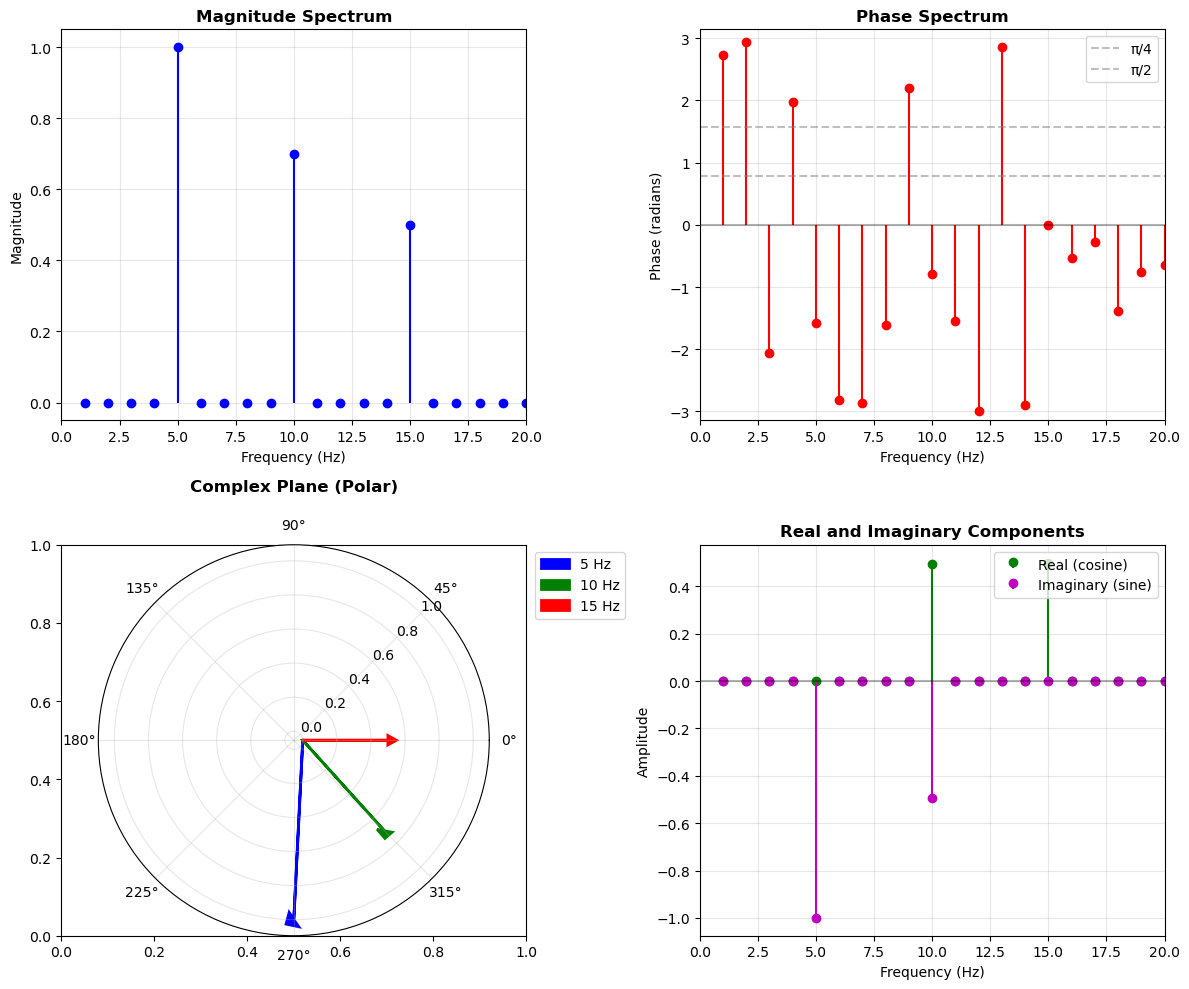

In [8]:
def complex_fft_visualization():
    """Visualize complex FFT output as magnitude and phase."""
    
    # Create a signal with known phase shifts
    fs = 100
    t = np.linspace(0, 1, fs, endpoint=False)
    
    # Three components with different phases
    signal = (1.0 * np.sin(2 * np.pi * 5 * t + 0) +        # 0 phase
             0.7 * np.sin(2 * np.pi * 10 * t + np.pi/4) +  # π/4 phase
             0.5 * np.sin(2 * np.pi * 15 * t + np.pi/2))   # π/2 phase
    
    # Compute FFT
    fft_vals = np.fft.fft(signal)
    freqs = np.fft.fftfreq(len(signal), 1/fs)
    
    # Get positive frequencies only
    pos_mask = freqs > 0
    freqs_pos = freqs[pos_mask]
    fft_pos = fft_vals[pos_mask]
    
    # Extract components
    magnitude = np.abs(fft_pos) / len(signal) * 2
    phase = np.angle(fft_pos)
    real_part = np.real(fft_pos) / len(signal) * 2
    imag_part = np.imag(fft_pos) / len(signal) * 2
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    
    # Magnitude spectrum
    axes[0, 0].stem(freqs_pos, magnitude, 'b', markerfmt='bo', basefmt=' ')
    axes[0, 0].set_title('Magnitude Spectrum', fontweight='bold')
    axes[0, 0].set_xlabel('Frequency (Hz)')
    axes[0, 0].set_ylabel('Magnitude')
    axes[0, 0].set_xlim(0, 20)
    axes[0, 0].grid(True, alpha=0.3)
    
    # Phase spectrum
    axes[0, 1].stem(freqs_pos, phase, 'r', markerfmt='ro', basefmt=' ')
    axes[0, 1].set_title('Phase Spectrum', fontweight='bold')
    axes[0, 1].set_xlabel('Frequency (Hz)')
    axes[0, 1].set_ylabel('Phase (radians)')
    axes[0, 1].set_xlim(0, 20)
    axes[0, 1].set_ylim(-np.pi, np.pi)
    axes[0, 1].axhline(0, color='k', linestyle='-', alpha=0.3)
    axes[0, 1].axhline(np.pi/4, color='gray', linestyle='--', alpha=0.5, label='π/4')
    axes[0, 1].axhline(np.pi/2, color='gray', linestyle='--', alpha=0.5, label='π/2')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend(loc='upper right')
    
    # Complex plane representation
    ax3 = fig.add_subplot(2, 2, 3, projection='polar')
    
    # Plot the three main components as vectors
    main_freqs = [5, 10, 15]
    colors = ['blue', 'green', 'red']
    for freq, color in zip(main_freqs, colors):
        idx = np.argmin(np.abs(freqs_pos - freq))
        if idx < len(magnitude):
            ax3.arrow(0, 0, phase[idx], magnitude[idx], 
                     head_width=0.1, head_length=0.05, 
                     fc=color, ec=color, linewidth=2,
                     label=f'{freq} Hz')
    
    ax3.set_title('Complex Plane (Polar)', fontweight='bold', pad=20)
    ax3.set_rlabel_position(45)
    ax3.grid(True, alpha=0.3)
    ax3.legend(loc='upper left', bbox_to_anchor=(1.1, 1))
    
    # Real vs Imaginary parts
    axes[1, 1].stem(freqs_pos, real_part, 'g', markerfmt='go', 
                   basefmt=' ', label='Real (cosine)')
    axes[1, 1].stem(freqs_pos, imag_part, 'm', markerfmt='mo', 
                   basefmt=' ', label='Imaginary (sine)')
    axes[1, 1].set_title('Real and Imaginary Components', fontweight='bold')
    axes[1, 1].set_xlabel('Frequency (Hz)')
    axes[1, 1].set_ylabel('Amplitude')
    axes[1, 1].set_xlim(0, 20)
    axes[1, 1].axhline(0, color='k', linestyle='-', alpha=0.3)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(loc='upper right')
    
    plt.tight_layout()
    plt.show()

complex_fft_visualization()

## Connection to GPU-Accelerated Processing

If you're using the `ionosense_hpc` ResearchEngine or similar GPU tools, these same concepts apply:

In [10]:
# Example comparison: CPU vs GPU (conceptual)
try:
    from ionosense_hpc.core import ResearchEngine, EngineConfig
    import time
    
    # Generate test signal
    fs = 48000
    duration = 1.0
    t = np.arange(0, duration, 1/fs)
    test_signal = np.sin(2 * np.pi * 1000 * t).astype(np.float32)
    
    # GPU processing
    config = EngineConfig()
    config.nfft = 2048
    config.batch = 1
    config.sample_rate_hz = fs
    
    engine = ResearchEngine()
    engine.initialize(config)
    
    # Time GPU
    start = time.time()
    gpu_result = engine.process(test_signal[:2048])
    gpu_time = time.time() - start
    
    # Time CPU
    start = time.time()
    cpu_result = np.abs(np.fft.rfft(test_signal[:2048] * np.hanning(2048)))
    cpu_time = time.time() - start
    
    print(f"GPU Processing Time: {gpu_time*1000:.3f} ms")
    print(f"CPU Processing Time: {cpu_time*1000:.3f} ms")
    print(f"Speedup: {cpu_time/gpu_time:.1f}x")
    
except ImportError:
    print("GPU acceleration not available - concepts still apply!")
    print("Key point: Whether using CPU or GPU, the fundamental")
    print("time-frequency trade-off remains exactly the same.")

GPU acceleration not available - concepts still apply!
Key point: Whether using CPU or GPU, the fundamental
time-frequency trade-off remains exactly the same.


## Common Pitfalls and Troubleshooting

### 1. DC Offset Issues
If your signal has a non-zero mean (DC offset), you'll see a large spike at 0 Hz:

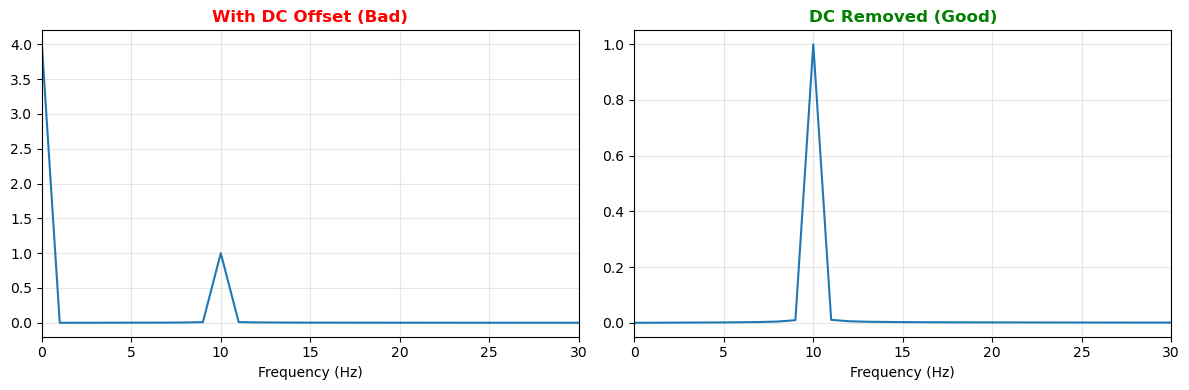

Tip: Always remove DC offset with: signal = signal - np.mean(signal)


In [11]:
# Demonstrate DC offset problem and solution
t = np.linspace(0, 1, 1000)
signal_with_dc = np.sin(2 * np.pi * 10 * t) + 2.0  # DC offset of 2.0
signal_no_dc = signal_with_dc - np.mean(signal_with_dc)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# With DC
fft1 = np.abs(np.fft.rfft(signal_with_dc))
freqs = np.fft.rfftfreq(len(signal_with_dc), 1/1000)
axes[0].plot(freqs, fft1/len(signal_with_dc)*2)
axes[0].set_title('With DC Offset (Bad)', fontweight='bold', color='red')
axes[0].set_xlabel('Frequency (Hz)')
axes[0].set_xlim(0, 30)
axes[0].grid(True, alpha=0.3)

# Without DC
fft2 = np.abs(np.fft.rfft(signal_no_dc))
axes[1].plot(freqs, fft2/len(signal_no_dc)*2)
axes[1].set_title('DC Removed (Good)', fontweight='bold', color='green')
axes[1].set_xlabel('Frequency (Hz)')
axes[1].set_xlim(0, 30)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Tip: Always remove DC offset with: signal = signal - np.mean(signal)")

## Module Summary

### Key Takeaways

1. **Sampling Theorem**: Sample at least 2× the highest frequency to avoid aliasing
2. **FFT Mechanics**: The FFT finds frequencies by correlation with sinusoids
3. **Resolution Trade-off**: Longer FFTs give better frequency resolution but worse time resolution
4. **Complex Output**: Magnitude tells you "how much", phase tells you "when/where"
5. **Practical Choices**: Choose FFT size based on your specific needs

### Quick Reference

```python
# Basic FFT workflow
signal = signal - np.mean(signal)  # Remove DC
fft_vals = np.fft.fft(signal)      # Compute FFT
freqs = np.fft.fftfreq(len(signal), 1/sample_rate)
magnitude = np.abs(fft_vals)
phase = np.angle(fft_vals)

# Frequency resolution
freq_resolution = sample_rate / fft_size
# Time resolution
time_resolution = fft_size / sample_rate
```

### What's Next?

In Module 2, we'll tackle a major problem with basic FFT analysis: spectral leakage. You'll learn how window functions solve this problem and how to choose the right window for your application.